# M8 Pipeline — Production Version
# M9 (k-NN Pool Huber) · gbr_all6 Stratification · MCC 5411

**Dataset:** MCC 5411 (Grocery Stores) · monthly `avg_proc_cost_pct` per merchant
**Task:** Predict processing cost % for months t+1, t+2, t+3 given 6 months of context
**Deployed model:** M9 (k-NN Pool Huber) with GBR residual-aware volatility stratification (all 6 risk features)

| Section | Content |
|---|---|
| §1 | Imports & configuration |
| §2 | Load data |
| §3 | Helper functions |
| §4 | Scenario generation, baseline & merchant split |
| §5 | Pool mean caches (flat + k-NN) |
| §6 | Model selection — rolling temporal CV |
| §7 | Final M9 model training & pool-local conformal calibration |
| §8 | Residual-aware volatility stratification (gbr_all6) |
| §9 | Final results & visualisations |

## §1 · Imports & Configuration

In [1]:
import os, math, warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings('ignore')

# ── Pipeline configuration ────────────────────────────────────────────────────
CONTEXT_LEN = 3
HORIZON_LEN = 3
TARGET_COV  = 0.90
MIN_POOL    = 10
KNN_K       = 10

## §2 · Load Data

In [2]:
df_5411_sample = pd.read_csv('df_5411_merchants_mthly_25th_Mar.csv')
display(df_5411_sample.head())

,merchant_id,year,month,transaction_count,avg_proc_cost_pct,total_processing_value,cost_type_1_pct,cost_type_2_pct,cost_type_3_pct,cost_type_4_pct,...,cost_type_56_pct,cost_type_57_pct,cost_type_58_pct,cost_type_59_pct,cost_type_60_pct,cost_type_61_pct,proc_cost_pct_lag_1,proc_cost_pct_lag_2,proc_cost_pct_lag_3,avg_transaction_value
0,5,2011,9,3,3.308678,27.060000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,9.020000
1,5,2011,11,1,4.371489,5.640000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.308678,NaN,NaN,5.640000
2,5,2012,12,9,2.213583,145.750000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,4.371489,3.308678,NaN,16.194444
3,20,2013,9,3,4.370629,11.349999,0.666667,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,3.783333
4,20,2014,1,1,2.499648,13.640000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,4.370629,NaN,NaN,13.640000


## §3 · Helper Functions

- **`get_test_scenario`** — slides a (context, horizon) window over a merchant's history
- **`generate_pool`** — returns all peer rows ≤ a given date, excluding the target merchant
- **`find_valid_merchants`** — filters to merchants with enough months for at least one scenario

In [3]:
def get_test_scenario(df, onboard_merchant_id, context_len, context_max_NAN_months,
                      horizon_len, horizon_max_NAN_months):
    merchant_data = df[df['merchant_id'] == onboard_merchant_id].copy()
    if len(merchant_data) == 0:
        return []

    merchant_data = merchant_data.sort_values(['year', 'month']).reset_index(drop=True)
    valid_scenarios = []

    for start_idx in range(len(merchant_data) - context_len - horizon_len + 1):
        context_end_idx = start_idx + context_len - 1
        context_window  = merchant_data.iloc[start_idx:context_end_idx + 1].copy().reset_index(drop=True)

        if len(context_window) > 0:
            context_start = (int(context_window.iloc[0]['year']),  int(context_window.iloc[0]['month']))
            context_end   = (int(context_window.iloc[-1]['year']), int(context_window.iloc[-1]['month']))
            expected_ctx  = (context_end[0] - context_start[0]) * 12 + (context_end[1] - context_start[1]) + 1
            nan_ctx       = expected_ctx - len(context_window)
        else:
            nan_ctx = context_len

        if nan_ctx > context_max_NAN_months or len(context_window) == 0:
            continue

        horizon_start_idx = context_end_idx + 1
        horizon_end_idx   = horizon_start_idx + horizon_len - 1

        if horizon_end_idx >= len(merchant_data):
            continue

        horizon_window = merchant_data.iloc[horizon_start_idx:horizon_end_idx + 1].copy().reset_index(drop=True)

        if len(horizon_window) > 0:
            horizon_start = (int(horizon_window.iloc[0]['year']),  int(horizon_window.iloc[0]['month']))
            horizon_end   = (int(horizon_window.iloc[-1]['year']), int(horizon_window.iloc[-1]['month']))
            expected_hor  = (horizon_end[0] - horizon_start[0]) * 12 + (horizon_end[1] - horizon_start[1]) + 1
            nan_hor       = expected_hor - len(horizon_window)
            ctx_hor_gap   = (horizon_start[0] - context_end[0]) * 12 + \
                             (horizon_start[1] - context_end[1]) - 1
        else:
            nan_hor     = horizon_len
            ctx_hor_gap = 999

        if nan_hor <= horizon_max_NAN_months and len(horizon_window) > 0 and ctx_hor_gap == 0:
            valid_scenarios.append({
                'context_data' : context_window,
                'horizon_data' : horizon_window,
                'context_range': (context_start, context_end),
                'horizon_range': (horizon_start, horizon_end),
                'context_gaps' : nan_ctx,
                'horizon_gaps' : nan_hor,
            })

    return valid_scenarios


def generate_pool(df, onboard_merchant_id, year, month):
    return df[
        (df['merchant_id'] != onboard_merchant_id) &
        ((df['year'] < year) | ((df['year'] == year) & (df['month'] <= month)))
    ].copy()


def find_valid_merchants(df, context_len, horizon_len, n_merchants=10, seed=42):
    rng_vm     = np.random.default_rng(seed)
    min_months = context_len + horizon_len
    all_ids    = rng_vm.permutation(df['merchant_id'].unique())
    valid = []
    for mid in all_ids:
        months = df[df['merchant_id'] == mid].groupby(['year', 'month']).size()
        if len(months) >= min_months:
            valid.append(mid)
            if len(valid) >= n_merchants:
                break
    return valid

## §4 · Scenario Generation, Baseline & Merchant Split

Slide a `(CONTEXT_LEN, HORIZON_LEN)` window over every merchant's history. Split merchants (not scenarios) into 60/20/20 groups to prevent data leakage.

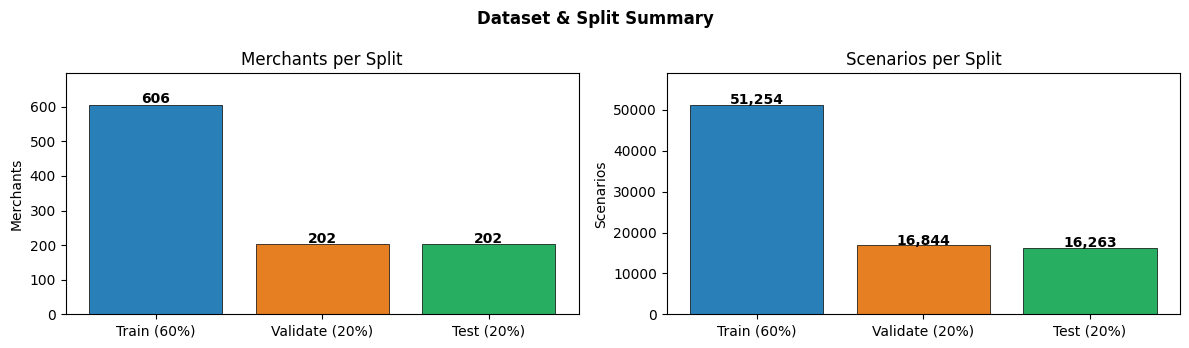

In [4]:
valid_merchants = find_valid_merchants(
    df_5411_sample, context_len=CONTEXT_LEN, horizon_len=HORIZON_LEN,
    n_merchants=5000, seed=42,
)

valid_test_scenarios_1 = []
for mid in valid_merchants:
    for s in get_test_scenario(
        df_5411_sample, mid,
        context_len=CONTEXT_LEN, context_max_NAN_months=0,
        horizon_len=HORIZON_LEN, horizon_max_NAN_months=0
    ):
        valid_test_scenarios_1.append({
            'merchant_id'  : mid,
            'context_data' : s['context_data'],
            'horizon_data' : s['horizon_data'],
            'context_range': s['context_range'],
            'horizon_range': s['horizon_range'],
            'context_gaps' : s['context_gaps'],
            'horizon_gaps' : s['horizon_gaps'],
        })

# Mean baseline
baseline_maes = []
for s in valid_test_scenarios_1:
    ctx_val  = float(np.mean(s['context_data']['avg_proc_cost_pct'].values))
    hor_vals = s['horizon_data']['avg_proc_cost_pct'].values
    baseline_maes.append(float(np.mean(np.abs(hor_vals - ctx_val))))
mean_baseline_mae_1 = float(np.mean(baseline_maes))

# ── Merchant-level 60/20/20 split ────────────────────────────────────────────
rng_split = np.random.default_rng(42)
all_mids  = sorted(set(s['merchant_id'] for s in valid_test_scenarios_1))
perm      = rng_split.permutation(len(all_mids))
n         = len(all_mids)
n_train   = int(0.60 * n)
n_val     = int(0.20 * n)

train_mids    = set(all_mids[i] for i in perm[:n_train])
validate_mids = set(all_mids[i] for i in perm[n_train : n_train + n_val])
test_mids     = set(all_mids[i] for i in perm[n_train + n_val :])

train_scenarios    = [s for s in valid_test_scenarios_1 if s['merchant_id'] in train_mids]
validate_scenarios = [s for s in valid_test_scenarios_1 if s['merchant_id'] in validate_mids]
test_scenarios     = [s for s in valid_test_scenarios_1 if s['merchant_id'] in test_mids]

assert not (train_mids & validate_mids)
assert not (train_mids & test_mids)
assert not (validate_mids & test_mids)

# ── Summary visualisation ─────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))
fig.suptitle('Dataset & Split Summary', fontsize=12, fontweight='bold')

split_labels = ['Train (60%)', 'Validate (20%)', 'Test (20%)']
split_mids   = [len(train_mids), len(validate_mids), len(test_mids)]
split_scens  = [len(train_scenarios), len(validate_scenarios), len(test_scenarios)]
colours      = ['#2980b9', '#e67e22', '#27ae60']

bars = ax1.bar(split_labels, split_mids, color=colours, edgecolor='k', linewidth=0.5)
for bar, v in zip(bars, split_mids):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 5, str(v), ha='center', fontsize=10, fontweight='bold')
ax1.set_ylabel('Merchants')
ax1.set_title('Merchants per Split')
ax1.set_ylim(0, max(split_mids) * 1.15)

bars = ax2.bar(split_labels, split_scens, color=colours, edgecolor='k', linewidth=0.5)
for bar, v in zip(bars, split_scens):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 200, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
ax2.set_ylabel('Scenarios')
ax2.set_title('Scenarios per Split')
ax2.set_ylim(0, max(split_scens) * 1.15)

plt.tight_layout()
plt.show()

## §5 · Pool Mean Caches

| Pool signal | Source |
|---|---|
| Flat pool mean | All peers ≤ context date, equally weighted |
| k-NN pool mean (k=10) | Top-10 by cosine payment-mix fingerprint similarity |

In [5]:
# ── Flat pool mean cache ───────────────────────────────────────────────────────
PMC_CSV = 'pool_mean_cache_5411_25th_Mar.csv'
pool_mean_cache = {}

if os.path.exists(PMC_CSV):
    pool_mean_cache_df = pd.read_csv(PMC_CSV)
    for _, row in pool_mean_cache_df.iterrows():
        pool_mean_cache[(row['merchant_id'], row['year'], row['month'])] = row['pool_mean']
else:
    unique_keys = {
        (s['merchant_id'],
         int(s['context_data'].iloc[-1]['year']),
         int(s['context_data'].iloc[-1]['month']))
        for s in valid_test_scenarios_1
    }
    for mid, yr, mo in unique_keys:
        pool = generate_pool(df_5411_sample, mid, yr, mo)
        pool_mean_cache[(mid, yr, mo)] = float(pool['avg_proc_cost_pct'].mean())

# ── k-NN pool mean cache ─────────────────────────────────────────────────────
COST_TYPE_COLS = [f'cost_type_{i}_pct' for i in range(1, 62)]
KNNPMC_CSV     = 'knn_pool_mean_cache_5411_25th_Mar.csv'
knn_pool_mean_cache = {}

if os.path.exists(KNNPMC_CSV):
    knn_pool_mean_cache_df = pd.read_csv(KNNPMC_CSV)
    for _, row in knn_pool_mean_cache_df.iterrows():
        knn_pool_mean_cache[(row['merchant_id'], row['year'], row['month'])] = row['pool_mean']
else:
    unique_keys = {
        (s['merchant_id'],
         int(s['context_data'].iloc[-1]['year']),
         int(s['context_data'].iloc[-1]['month']))
        for s in valid_test_scenarios_1
    }
    keys_by_date = defaultdict(list)
    for mid, yr, mo in unique_keys:
        keys_by_date[(yr, mo)].append(mid)

    for (yr, mo), query_mids in sorted(keys_by_date.items()):
        snap     = df_5411_sample[
            (df_5411_sample['year'] < yr) |
            ((df_5411_sample['year'] == yr) & (df_5411_sample['month'] <= mo))
        ]
        fp_all   = snap.groupby('merchant_id')[COST_TYPE_COLS].mean()
        cost_all = snap.groupby('merchant_id')['avg_proc_cost_pct'].mean()

        if len(fp_all) < KNN_K + 1:
            for mid in query_mids:
                knn_pool_mean_cache[(mid, yr, mo)] = pool_mean_cache[(mid, yr, mo)]
            continue

        nn_date = NearestNeighbors(n_neighbors=min(KNN_K + 1, len(fp_all)), metric='cosine')
        nn_date.fit(fp_all.values)
        fp_index = fp_all.index.tolist()

        for mid in query_mids:
            ctx_row = df_5411_sample[
                (df_5411_sample['merchant_id'] == mid) &
                (df_5411_sample['year'] == yr) &
                (df_5411_sample['month'] == mo)
            ]
            if len(ctx_row) == 0 or mid not in fp_all.index:
                knn_pool_mean_cache[(mid, yr, mo)] = pool_mean_cache[(mid, yr, mo)]
                continue

            _, raw_idx = nn_date.kneighbors(ctx_row[COST_TYPE_COLS].values)
            top_ids    = [fp_index[i] for i in raw_idx[0] if fp_index[i] != mid][:KNN_K]

            if len(top_ids) < KNN_K:
                knn_pool_mean_cache[(mid, yr, mo)] = pool_mean_cache[(mid, yr, mo)]
            else:
                knn_pool_mean_cache[(mid, yr, mo)] = float(cost_all.loc[top_ids].mean())

print(f'Flat pool mean cache: {len(pool_mean_cache):,} entries')
print(f'k-NN pool mean cache: {len(knn_pool_mean_cache):,} entries')

Flat pool mean cache: 90,939 entries
k-NN pool mean cache: 90,939 entries


## §6 · Model Selection — Rolling Temporal CV

Three `HuberRegressor` models (ε = 1.35) per horizon step:

| Model | Pool signal | Training target |
|---|---|---|
| M8 | Flat pool mean | `avg_proc_cost_pct` |
| M9 | k-NN pool mean (cosine top-10) | `avg_proc_cost_pct` |
| M10 | k-NN pool mean | `avg_proc_cost_pct − pool_mean` (deviation) |

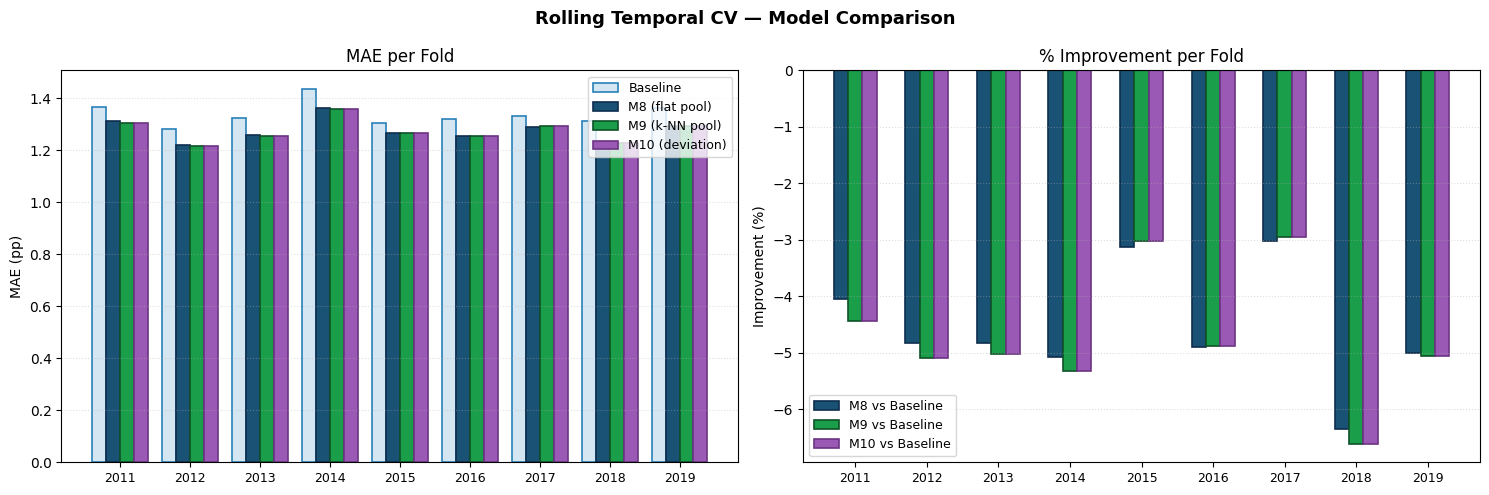

,cut_year,n_test,baseline_mae,m8_mae,m9_mae,m10_mae,m8_impr,m9_impr,m10_impr
0,2011,5218,1.3653,1.3100,1.3047,1.3047,-4.0500,-4.4400,-4.4400
1,2012,5393,1.2811,1.2193,1.2158,1.2158,-4.8200,-5.1000,-5.1000
2,2013,5358,1.3217,1.2580,1.2552,1.2552,-4.8200,-5.0300,-5.0300
3,2014,5492,1.4348,1.3621,1.3583,1.3583,-5.0700,-5.3300,-5.3300
4,2015,5619,1.3044,1.2637,1.2650,1.2650,-3.1200,-3.0200,-3.0200
5,2016,5562,1.3184,1.2538,1.2540,1.2540,-4.9000,-4.8800,-4.8800
6,2017,5535,1.3304,1.2902,1.2909,1.2909,-3.0200,-2.9600,-2.9600
7,2018,5617,1.3130,1.2295,1.2262,1.2262,-6.3600,-6.6100,-6.6100
8,2019,3712,1.3607,1.2926,1.2920,1.2920,-5.0100,-5.0500,-5.0500


In [6]:
FEAT_NAMES_M8 = ['context_mean', 'context_std', 'momentum', 'pool_mean']


def build_features_m8(scenarios, cache):
    rows = []
    for s in scenarios:
        vals   = s['context_data']['avg_proc_cost_pct'].values
        c_mean = float(np.mean(vals))
        c_std  = float(np.std(vals))
        mom    = float(vals[-1] - c_mean)
        key    = (s['merchant_id'],
                  int(s['context_data'].iloc[-1]['year']),
                  int(s['context_data'].iloc[-1]['month']))
        p_mean = cache[key]
        rows.append([c_mean, c_std, mom, p_mean])
    return np.array(rows, dtype=float)


# ── Rolling temporal CV ───────────────────────────────────────────────────────
_all_years   = sorted({int(s['horizon_data'].iloc[0]['year']) for s in train_scenarios})
fold_cuts    = _all_years[1:]
fold_results = []

for cut in fold_cuts:
    train_fold = [s for s in train_scenarios if int(s['horizon_data'].iloc[-1]['year']) < cut]
    test_fold  = [s for s in train_scenarios if int(s['horizon_data'].iloc[0]['year']) == cut]
    if not train_fold or not test_fold:
        continue

    y_tr_fold = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in train_fold])
    y_te_fold = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in test_fold])

    base_preds = np.array(
        [[np.mean(s['context_data']['avg_proc_cost_pct'].values)] * HORIZON_LEN for s in test_fold]
    )
    base_mae = float(np.mean(np.abs(y_te_fold - base_preds)))

    def _train_eval(cache_tr, cache_te, y_target_tr=None, pool_add_back=None):
        X_raw_tr = build_features_m8(train_fold, cache_tr)
        X_raw_te = build_features_m8(test_fold, cache_te)
        sw_ = 1.0 / (X_raw_tr[:, 3] + 1.0)
        sc_ = StandardScaler()
        Xtr_ = sc_.fit_transform(X_raw_tr)
        Xte_ = sc_.transform(X_raw_te)
        preds_ = np.zeros_like(y_te_fold, dtype=float)
        tgt = y_target_tr if y_target_tr is not None else y_tr_fold
        for i in range(HORIZON_LEN):
            m = HuberRegressor(epsilon=1.35, max_iter=500)
            m.fit(Xtr_, tgt[:, i], sample_weight=sw_)
            preds_[:, i] = m.predict(Xte_)
        if pool_add_back is not None:
            preds_ += pool_add_back[:, None]
        return float(np.mean(np.abs(y_te_fold - preds_)))

    m8_mae  = _train_eval(pool_mean_cache, pool_mean_cache)
    m9_mae  = _train_eval(knn_pool_mean_cache, knn_pool_mean_cache)

    X_tr_dev_raw = build_features_m8(train_fold, knn_pool_mean_cache)
    X_te_dev_raw = build_features_m8(test_fold, knn_pool_mean_cache)
    y_tr_dev     = y_tr_fold - X_tr_dev_raw[:, 3][:, None]
    m10_mae = _train_eval(knn_pool_mean_cache, knn_pool_mean_cache,
                          y_target_tr=y_tr_dev, pool_add_back=X_te_dev_raw[:, 3])

    fold_results.append({
        'cut_year': cut, 'n_test': len(test_fold),
        'baseline_mae': round(base_mae, 6),
        'm8_mae': round(m8_mae, 6), 'm9_mae': round(m9_mae, 6), 'm10_mae': round(m10_mae, 6),
        'm8_impr': round((m8_mae  - base_mae) / base_mae * 100, 2),
        'm9_impr': round((m9_mae  - base_mae) / base_mae * 100, 2),
        'm10_impr': round((m10_mae - base_mae) / base_mae * 100, 2),
    })

df_folds = pd.DataFrame(fold_results)

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Rolling Temporal CV — Model Comparison', fontsize=13, fontweight='bold')

fold_labels = [str(r['cut_year']) for r in fold_results]
x     = np.arange(len(fold_labels))
bar_w = 0.2

ax1.bar(x - 1.5*bar_w, [r['baseline_mae'] for r in fold_results], bar_w,
        label='Baseline', color='#d4e6f1', edgecolor='#2980b9', linewidth=1.2)
ax1.bar(x - 0.5*bar_w, [r['m8_mae'] for r in fold_results], bar_w,
        label='M8 (flat pool)', color='#1a5276', edgecolor='#0e2d4e', linewidth=1.2)
ax1.bar(x + 0.5*bar_w, [r['m9_mae'] for r in fold_results], bar_w,
        label='M9 (k-NN pool)', color='#1a9e4a', edgecolor='#0e5228', linewidth=1.2)
ax1.bar(x + 1.5*bar_w, [r['m10_mae'] for r in fold_results], bar_w,
        label='M10 (deviation)', color='#9b59b6', edgecolor='#6c3483', linewidth=1.2)
ax1.set_xticks(x); ax1.set_xticklabels(fold_labels, fontsize=9)
ax1.set_ylabel('MAE (pp)'); ax1.set_title('MAE per Fold')
ax1.legend(fontsize=9); ax1.grid(axis='y', linestyle=':', alpha=0.4)

ax2.bar(x - bar_w, [r['m8_impr'] for r in fold_results], bar_w,
        label='M8 vs Baseline', color='#1a5276', edgecolor='#0e2d4e', linewidth=1.2)
ax2.bar(x, [r['m9_impr'] for r in fold_results], bar_w,
        label='M9 vs Baseline', color='#1a9e4a', edgecolor='#0e5228', linewidth=1.2)
ax2.bar(x + bar_w, [r['m10_impr'] for r in fold_results], bar_w,
        label='M10 vs Baseline', color='#9b59b6', edgecolor='#6c3483', linewidth=1.2)
ax2.axhline(0, color='black', lw=0.8, alpha=0.5)
ax2.set_xticks(x); ax2.set_xticklabels(fold_labels, fontsize=9)
ax2.set_ylabel('Improvement (%)'); ax2.set_title('% Improvement per Fold')
ax2.legend(fontsize=9); ax2.grid(axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

avg_base = df_folds['baseline_mae'].mean()
avg_m9   = df_folds['m9_mae'].mean()

# Summary table
display(df_folds.style.set_caption(
    f"Rolling CV — M9 selected (avg MAE {avg_m9:.4f}, "
    f"{(avg_m9 - avg_base)/avg_base*100:+.2f}% vs baseline {avg_base:.4f})"
).format(precision=4))

## §7 · Final M9 Model Training & Pool-Local Conformal Calibration

| Set | Merchant group | Temporal filter | Role |
|---|---|---|---|
| `train_ci` | train (60%) | horizon < cal year | Fit M9 final models |
| `cal_ci` | validate (20%) | horizon == cal year | Conformal calibration — unseen merchants |
| `test_ci` | test (20%) | horizon == test year | Fully held-out evaluation |

In [7]:
def adaptive_q(residuals, target=TARGET_COV):
    n     = len(residuals)
    level = math.ceil((n + 1) * target) / n
    return float(np.quantile(residuals, level)) if level <= 1.0 else None


# ── Temporal partition ────────────────────────────────────────────────────────
_ci_years  = sorted({int(s['horizon_data'].iloc[0]['year']) for s in valid_test_scenarios_1})
_cal_year  = _ci_years[-2]
_test_year = _ci_years[-1]

train_ci = [s for s in train_scenarios    if int(s['horizon_data'].iloc[0]['year']) < _cal_year]
cal_ci   = [s for s in validate_scenarios if int(s['horizon_data'].iloc[0]['year']) == _cal_year]
test_ci  = [s for s in test_scenarios     if int(s['horizon_data'].iloc[0]['year']) == _test_year]

y_tr  = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in train_ci])
y_cal = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in cal_ci])
y_te  = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in test_ci])

# ── M9: k-NN pool mean — final fit ───────────────────────────────────────────
X_tr_knn_raw  = build_features_m8(train_ci, knn_pool_mean_cache)
X_cal_knn_raw = build_features_m8(cal_ci,   knn_pool_mean_cache)
X_te_knn_raw  = build_features_m8(test_ci,  knn_pool_mean_cache)
sw_knn        = 1.0 / (X_tr_knn_raw[:, 3] + 1.0)

scaler_knn = StandardScaler()
X_tr_knn  = scaler_knn.fit_transform(X_tr_knn_raw)
X_cal_knn = scaler_knn.transform(X_cal_knn_raw)
X_te_knn  = scaler_knn.transform(X_te_knn_raw)

cal_preds_knn = np.zeros_like(y_cal, dtype=float)
te_preds_knn  = np.zeros_like(y_te,  dtype=float)
models_knn    = []

for h in range(HORIZON_LEN):
    m = HuberRegressor(epsilon=1.35, max_iter=500)
    m.fit(X_tr_knn, y_tr[:, h], sample_weight=sw_knn)
    cal_preds_knn[:, h] = m.predict(X_cal_knn)
    te_preds_knn[:, h]  = m.predict(X_te_knn)
    models_knn.append(m)

cal_max_res_knn = np.abs(y_cal - cal_preds_knn).max(axis=1)
q90_global_knn  = float(np.quantile(cal_max_res_knn, 0.90))

# ── Pool-local conformal (M9 baseline) ───────────────────────────────────────
cal_merchant_ids = np.array([s['merchant_id'] for s in cal_ci])
merchant_cal_res_knn = defaultdict(list)
for i, res in enumerate(cal_max_res_knn):
    merchant_cal_res_knn[int(cal_merchant_ids[i])].append(float(res))

hw_per_scenario_knn = np.zeros(len(test_ci))
for i, s in enumerate(test_ci):
    yr, mo    = s['context_range'][1]
    peer_mids = set(int(p) for p in
                    generate_pool(df_5411_sample, int(s['merchant_id']), yr, mo)['merchant_id'].unique())
    peer_res  = [r for peer in peer_mids for r in merchant_cal_res_knn.get(peer, [])]

    q_local = adaptive_q(peer_res) if len(peer_res) >= MIN_POOL else None
    hw_per_scenario_knn[i] = q_local if q_local is not None else q90_global_knn

lo_pool_knn = np.clip(te_preds_knn - hw_per_scenario_knn[:, None], 0, None)
hi_pool_knn = te_preds_knn + hw_per_scenario_knn[:, None]

in_pool_knn    = (y_te >= lo_pool_knn) & (y_te <= hi_pool_knn)
joint_pool_knn = float(np.mean(in_pool_knn.all(axis=1)))
width_pool_knn = float(np.mean(hi_pool_knn - lo_pool_knn))

print(f'M9 pool-local conformal @ {TARGET_COV*100:.0f}%:  '
      f'joint_cov={joint_pool_knn:.3f}  avg_hw=±{width_pool_knn/2:.4f}')

M9 pool-local conformal @ 90%:  joint_cov=0.934  avg_hw=±4.5077


## §8 · Residual-Aware Volatility Stratification (gbr_all6)

A GBR risk model trained on cross-fitted M9 residuals ranks merchants by coverage difficulty.
The risk score drives a continuous monotone width-adjustment curve, assigning wider intervals
to volatile merchants and tighter intervals to stable ones.

| Component | Detail |
|---|---|
| Risk features | 6 (4 context + 2 peer-pool) |
| Risk model | GradientBoostingRegressor (120 trees, depth 2) |
| Scheme selection | Auto-select from candidate percentile grids on calibration holdout |
| Guard | Soft floor = TARGET_COV − 0.03 |

In [15]:
_VOL_EPS         = 1e-6
VOL_MIN_GAIN_ABS = 0.00
VOL_MIN_GAIN_REL = 0.00
VOL_TEST_COV_SLACK = 1.0

RISK_FEATURE_NAMES = [
    'ctx_cov', 'ctx_range_ratio', 'ctx_slope_ratio',
    'ctx_last_jump_ratio', 'pool_mean_gap_ratio', 'ctx_to_knn_gap_ratio',
]

VOL_BUCKET_SCHEMES = {
    'low-mid-high_50_85':          [0.00, 0.50, 0.85, 1.00],
    'low-mid-high_40_80':          [0.00, 0.40, 0.80, 1.00],
    'low-mid-high_60_90':          [0.00, 0.60, 0.90, 1.00],
    'low-mid-high-vhigh_50_75_90': [0.00, 0.50, 0.75, 0.90, 1.00],
    'low-mid-high-vhigh_40_70_88': [0.00, 0.40, 0.70, 0.88, 1.00],
    'low-mid-high-vhigh_60_85_95': [0.00, 0.60, 0.85, 0.95, 1.00],
}

VOL_LABELS_BY_COUNT = {
    1: ['Global'], 2: ['Low', 'High'],
    3: ['Low', 'Mid', 'High'], 4: ['Low', 'Mid', 'High', 'VHigh'],
}


def risk_features(s):
    vals   = s['context_data']['avg_proc_cost_pct'].values.astype(float)
    c_mean = float(np.mean(vals))
    _denom = c_mean + _VOL_EPS

    ctx_cov         = float(np.std(vals)) / _denom
    ctx_range_ratio = (float(np.max(vals)) - float(np.min(vals))) / _denom
    x_idx           = np.arange(len(vals), dtype=float)
    ctx_slope_ratio = float(np.polyfit(x_idx, vals, 1)[0]) / _denom
    ctx_last_jump_ratio = (float(vals[-1]) - float(vals[-2])) / _denom if len(vals) >= 2 else 0.0

    yr, mo  = s['context_range'][1]
    mid     = int(s['merchant_id'])
    flat_pm = float(pool_mean_cache.get((mid, yr, mo), c_mean))
    knn_pm  = float(knn_pool_mean_cache.get((mid, yr, mo), c_mean))

    pool_mean_gap_ratio  = abs(c_mean - flat_pm) / (flat_pm + _VOL_EPS)
    ctx_to_knn_gap_ratio = abs(c_mean - knn_pm)  / (knn_pm  + _VOL_EPS)

    return np.array([ctx_cov, ctx_range_ratio, ctx_slope_ratio, ctx_last_jump_ratio,
                     pool_mean_gap_ratio, ctx_to_knn_gap_ratio], dtype=float)


def _effective_half_width(lo, hi):
    return (hi - lo) / 2.0


# ── 1. Compute risk features ─────────────────────────────────────────────────
train_feat = np.vstack([risk_features(s) for s in train_ci]).astype(float)
cal_feat   = np.vstack([risk_features(s) for s in cal_ci]).astype(float)
te_feat    = np.vstack([risk_features(s) for s in test_ci]).astype(float)

# ── 2. Cross-fitted residual targets ─────────────────────────────────────────
train_years  = np.array([int(s['horizon_data'].iloc[0]['year']) for s in train_ci])
train_cf_res = np.full((len(train_ci), HORIZON_LEN), np.nan, dtype=float)

for cut in fold_cuts:
    cf_train_mask = train_years < cut
    cf_test_mask  = train_years == cut
    if cf_train_mask.sum() == 0 or cf_test_mask.sum() == 0:
        continue

    cf_train = [train_ci[i] for i in np.where(cf_train_mask)[0]]
    cf_test  = [train_ci[i] for i in np.where(cf_test_mask)[0]]
    y_cf_train = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in cf_train])
    y_cf_test  = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in cf_test])

    X_cf_train_raw = build_features_m8(cf_train, knn_pool_mean_cache)
    X_cf_test_raw  = build_features_m8(cf_test,  knn_pool_mean_cache)
    sw_cf = 1.0 / (X_cf_train_raw[:, 3] + 1.0)

    scaler_cf  = StandardScaler()
    X_cf_train = scaler_cf.fit_transform(X_cf_train_raw)
    X_cf_test  = scaler_cf.transform(X_cf_test_raw)

    preds_cf = np.zeros_like(y_cf_test, dtype=float)
    for h in range(HORIZON_LEN):
        model_cf = HuberRegressor(epsilon=1.35, max_iter=500)
        model_cf.fit(X_cf_train, y_cf_train[:, h], sample_weight=sw_cf)
        preds_cf[:, h] = model_cf.predict(X_cf_test)

    train_cf_res[cf_test_mask] = np.abs(y_cf_test - preds_cf)

cf_valid_mask = np.isfinite(train_cf_res).all(axis=1)

# ── 3. GBR risk model (all 6 features) ───────────────────────────────────────
risk_models = []
for h in range(HORIZON_LEN):
    model = GradientBoostingRegressor(
        loss='squared_error', n_estimators=120, learning_rate=0.05,
        max_depth=2, min_samples_leaf=max(20, MIN_POOL),
        subsample=0.8, random_state=4121,
    )
    model.fit(train_feat[cf_valid_mask], np.log1p(train_cf_res[cf_valid_mask, h].astype(float)))
    risk_models.append(model)

cal_risk_score = np.max(np.column_stack([m.predict(cal_feat) for m in risk_models]), axis=1)
te_risk_score  = np.max(np.column_stack([m.predict(te_feat)  for m in risk_models]), axis=1)

# ── 4. Leak-free scheme selection on calibration holdout ──────────────────────
_VOL_SELECT_SEED = 4121
_VOL_SELECT_FRAC = 0.70

_cal_mids = np.array(sorted(set(cal_merchant_ids.tolist())))
_rng  = np.random.default_rng(_VOL_SELECT_SEED)
_perm = _rng.permutation(_cal_mids)
_cut  = min(max(1, int(round(len(_perm) * _VOL_SELECT_FRAC))), len(_perm) - 1)
_sel_mids = set(_perm[:_cut].tolist())

sel_mask  = np.isin(cal_merchant_ids, list(_sel_mids))
eval_mask = ~sel_mask

y_eval         = y_cal[eval_mask]
preds_eval_knn = cal_preds_knn[eval_mask]
eval_ci        = [cal_ci[i] for i in np.where(eval_mask)[0]]

merchant_sel_res_knn = defaultdict(list)
for mid, res in zip(cal_merchant_ids[sel_mask], cal_max_res_knn[sel_mask]):
    merchant_sel_res_knn[int(mid)].append(float(res))

global_q_sel_knn = adaptive_q(cal_max_res_knn[sel_mask].tolist())
if global_q_sel_knn is None:
    global_q_sel_knn = q90_global_knn

# Baseline on holdout
hw_eval_pool = np.zeros(eval_mask.sum(), dtype=float)
for i, s in enumerate(eval_ci):
    yr, mo    = s['context_range'][1]
    peer_mids = set(int(p) for p in generate_pool(df_5411_sample, int(s['merchant_id']), yr, mo)['merchant_id'].unique())
    peer_res  = [r for peer in peer_mids for r in merchant_sel_res_knn.get(peer, [])]
    q_local   = adaptive_q(peer_res) if len(peer_res) >= MIN_POOL else None
    hw_eval_pool[i] = q_local if q_local is not None else global_q_sel_knn

lo_eval_pool = np.clip(preds_eval_knn - hw_eval_pool[:, None], 0, None)
hi_eval_pool = preds_eval_knn + hw_eval_pool[:, None]
in_eval_pool = (y_eval >= lo_eval_pool) & (y_eval <= hi_eval_pool)

baseline_eval = {
    'avg_hw': float(np.mean(_effective_half_width(lo_eval_pool, hi_eval_pool))),
    'joint_cov': float(np.mean(in_eval_pool.all(axis=1))),
}
_min_gain_holdout = max(VOL_MIN_GAIN_ABS, VOL_MIN_GAIN_REL * baseline_eval['avg_hw'])

sel_risk_score  = cal_risk_score[sel_mask]
eval_risk_score = cal_risk_score[eval_mask]


def _make_percentile_bins(ref_vals, apply_vals, pct_edges, min_count=MIN_POOL):
    pct_edges = np.array(pct_edges, dtype=float)
    edges = np.quantile(ref_vals, pct_edges)
    edges = np.maximum.accumulate(edges)
    edges = np.unique(edges)
    n_eff = len(edges) - 1
    if n_eff < 2:
        return None
    ref_bins   = np.digitize(ref_vals,   edges[1:-1], right=False)
    counts     = np.array([(ref_bins == b).sum() for b in range(n_eff)])
    if counts.min() < min_count:
        return None
    apply_bins = np.digitize(apply_vals, edges[1:-1], right=False)
    return edges, ref_bins, apply_bins, n_eff, counts


def _continuous_width_map(cal_scores_ref, apply_scores, cal_res, pct_edges, q_fallback):
    built = _make_percentile_bins(cal_scores_ref, apply_scores, pct_edges, min_count=MIN_POOL)
    if built is None:
        return None
    edges, ref_bins, apply_bins, n_eff, counts = built
    q_vals = []
    for b in range(n_eff):
        res_b   = cal_res[ref_bins == b].tolist()
        q_local = adaptive_q(res_b) if len(res_b) >= MIN_POOL else None
        q_vals.append(q_local if q_local is not None else q_fallback)
    q_vals = np.maximum.accumulate(np.array(q_vals, dtype=float))
    knot_x = 0.5 * (edges[:-1] + edges[1:])
    knot_x = np.maximum.accumulate(knot_x + np.arange(len(knot_x)) * 1e-9)
    hw_apply = np.interp(apply_scores, knot_x, q_vals, left=q_vals[0], right=q_vals[-1])
    return {
        'edges': edges, 'ref_bins': ref_bins, 'apply_bins': apply_bins,
        'active': n_eff, 'counts': counts, 'knot_x': knot_x,
        'q_vals': q_vals, 'hw_apply': hw_apply,
    }


# ── Auto-select best scheme ──────────────────────────────────────────────────
_scheme_results = []
for _name, _pct in VOL_BUCKET_SCHEMES.items():
    mapped = _continuous_width_map(sel_risk_score, eval_risk_score, cal_max_res_knn[sel_mask], _pct, global_q_sel_knn)
    if mapped is None:
        continue
    hw = mapped['hw_apply']
    lo_ = np.clip(preds_eval_knn - hw[:, None], 0, None)
    hi_ = preds_eval_knn + hw[:, None]
    in_ = (y_eval >= lo_) & (y_eval <= hi_)
    avg_hw    = float(np.mean(_effective_half_width(lo_, hi_)))
    joint_cov = float(np.mean(in_.all(axis=1)))
    _res = {'name': _name, 'pct_edges': np.array(_pct, dtype=float), 'active': mapped['active'],
            'avg_hw': avg_hw, 'joint_cov': joint_cov,
            'gain_vs_baseline': baseline_eval['avg_hw'] - avg_hw}
    _scheme_results.append(_res)

_feasible = [r for r in _scheme_results
             if (r['joint_cov'] >= TARGET_COV) and (r['gain_vs_baseline'] >= _min_gain_holdout)]
_USE_STRATIFIED_VOL = bool(_feasible)
_best = min(_feasible, key=lambda r: (r['avg_hw'], r['active'])) if _USE_STRATIFIED_VOL else None

# ── Build deployed intervals ─────────────────────────────────────────────────
if _USE_STRATIFIED_VOL:
    _display = _make_percentile_bins(cal_risk_score, te_risk_score, _best['pct_edges'], min_count=MIN_POOL)
    if _display is None:
        _USE_STRATIFIED_VOL = False

if _USE_STRATIFIED_VOL:
    VOL_SCHEME_NAME = _best['name']
    VOL_EDGES, cal_vol_bins, te_vol_bins, N_VOL_BINS_ACTIVE, _ = _display
else:
    VOL_SCHEME_NAME    = 'global_fallback'
    VOL_EDGES          = np.array([float(np.min(cal_risk_score)), float(np.max(cal_risk_score) + _VOL_EPS)])
    cal_vol_bins       = np.zeros(len(cal_risk_score), dtype=int)
    te_vol_bins        = np.zeros(len(te_risk_score), dtype=int)
    N_VOL_BINS_ACTIVE  = 1

VOL_LABELS_ACTIVE = VOL_LABELS_BY_COUNT.get(N_VOL_BINS_ACTIVE, [f'B{b+1}' for b in range(N_VOL_BINS_ACTIVE)])

# M9 stratified intervals
if _USE_STRATIFIED_VOL:
    mapped_m9 = _continuous_width_map(cal_risk_score, te_risk_score, cal_max_res_knn, _best['pct_edges'], q90_global_knn)
    hw_strat_m9 = mapped_m9['hw_apply']
else:
    hw_strat_m9 = hw_per_scenario_knn.copy()

lo_strat_m9 = np.clip(te_preds_knn - hw_strat_m9[:, None], 0, None)
hi_strat_m9 = te_preds_knn + hw_strat_m9[:, None]

# ── Deployment guard ──────────────────────────────────────────────────────────
_candidate_joint_m9  = float(np.mean(((y_te >= lo_strat_m9) & (y_te <= hi_strat_m9)).all(axis=1)))
_candidate_avg_hw_m9 = float(np.mean(_effective_half_width(lo_strat_m9, hi_strat_m9)))
_global_avg_hw_m9    = float(np.mean(_effective_half_width(lo_pool_knn, hi_pool_knn)))
_coverage_floor_test = TARGET_COV - VOL_TEST_COV_SLACK
_min_gain_test       = max(VOL_MIN_GAIN_ABS, VOL_MIN_GAIN_REL * _global_avg_hw_m9)

if (VOL_SCHEME_NAME != 'global_fallback') and not (
    (_candidate_joint_m9 >= _coverage_floor_test) and ((_global_avg_hw_m9 - _candidate_avg_hw_m9) >= _min_gain_test)
):
    VOL_SCHEME_NAME   = 'global_fallback'
    hw_strat_m9       = hw_per_scenario_knn.copy()
    lo_strat_m9       = lo_pool_knn.copy()
    hi_strat_m9       = hi_pool_knn.copy()
    te_vol_bins       = np.zeros(len(te_risk_score), dtype=int)
    N_VOL_BINS_ACTIVE = 1
    VOL_LABELS_ACTIVE = ['Global']

# Final deployed metrics
deployed_joint_cov = float(np.mean(((y_te >= lo_strat_m9) & (y_te <= hi_strat_m9)).all(axis=1)))
deployed_avg_hw    = float(np.mean(_effective_half_width(lo_strat_m9, hi_strat_m9)))

print(f'Deployed scheme: {VOL_SCHEME_NAME}  |  bins: {N_VOL_BINS_ACTIVE}')
print(f'Test joint coverage: {deployed_joint_cov:.4f}  |  Avg half-width: ±{deployed_avg_hw:.4f}')
print(f'Width reduction vs flat baseline: {(deployed_avg_hw - _global_avg_hw_m9) / _global_avg_hw_m9 * 100:+.1f}%')

Deployed scheme: global_fallback  |  bins: 1
Test joint coverage: 0.9341  |  Avg half-width: ±4.5077
Width reduction vs flat baseline: +0.0%


## §9 · Final Results

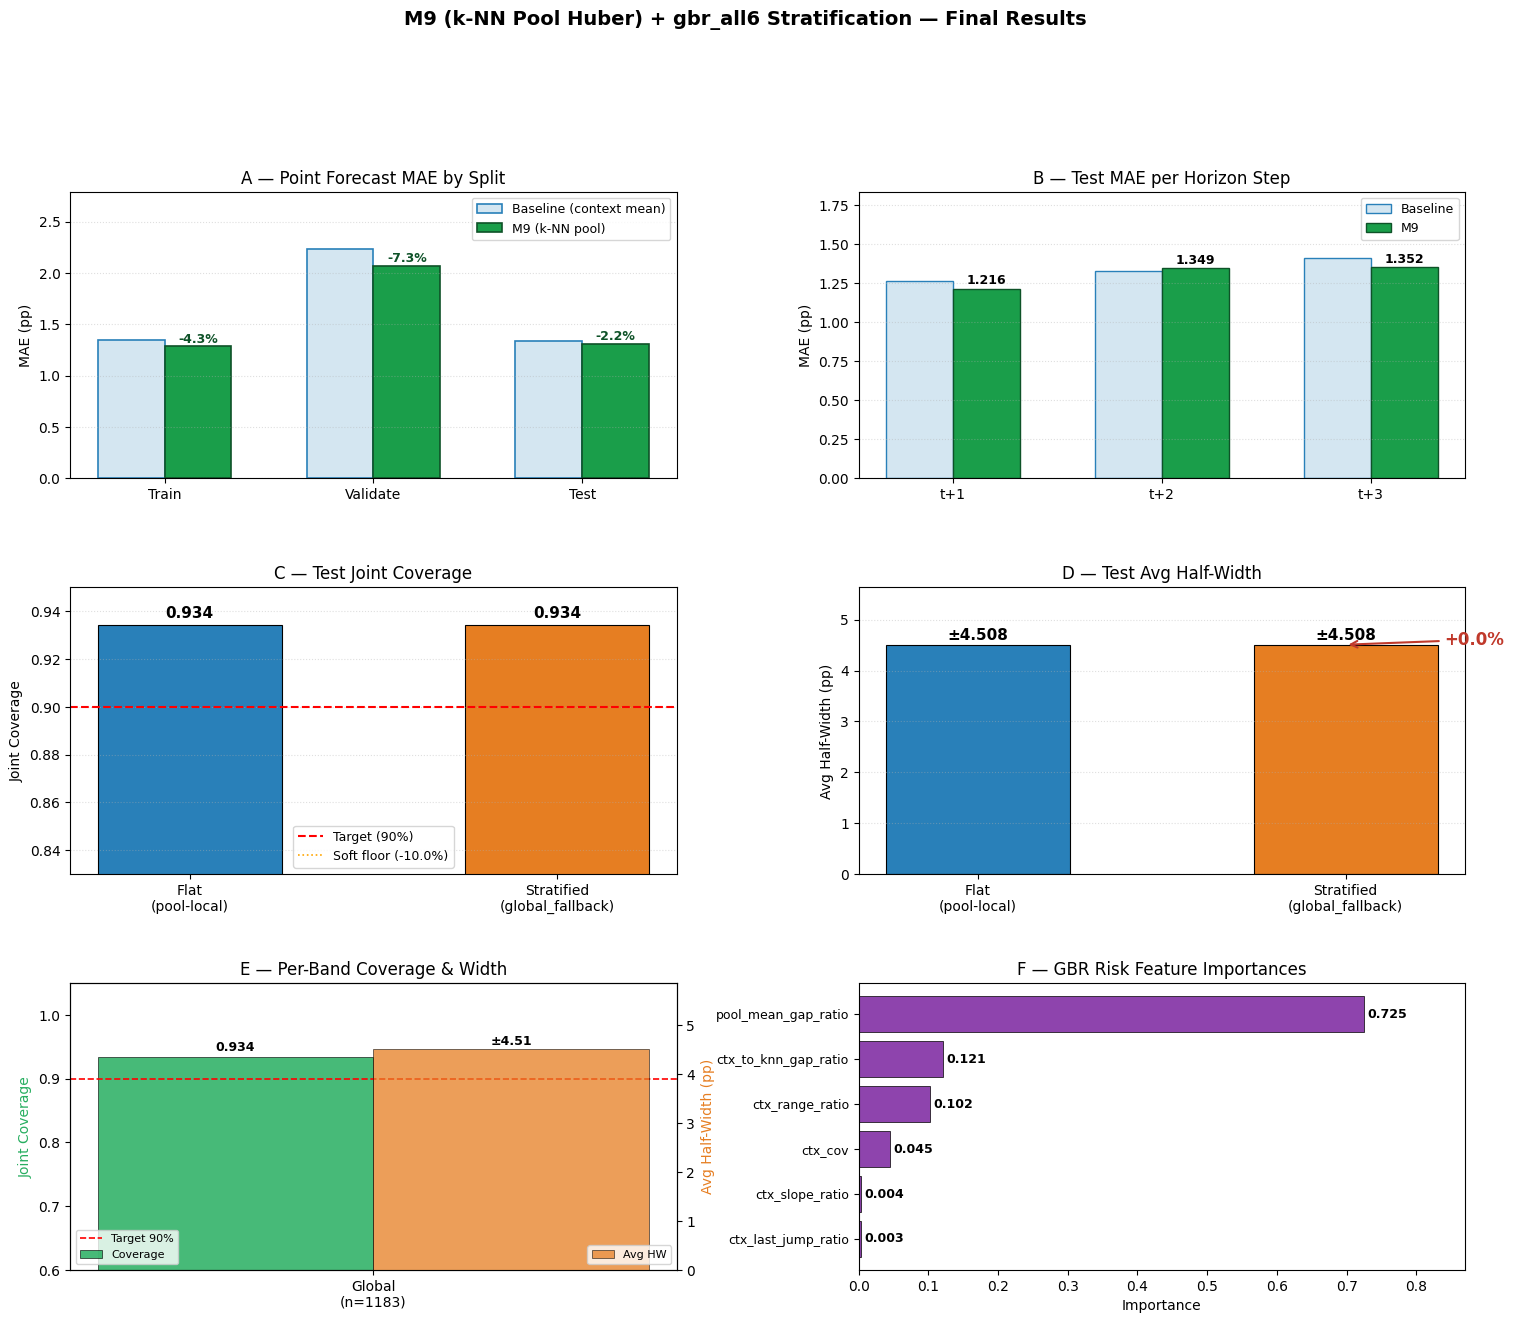

In [16]:
# ── Baseline predictions ───────────────────────────────────────────────────────
base_tr_preds = np.array([[np.mean(s['context_data']['avg_proc_cost_pct'].values)] * 3 for s in train_ci])
base_cal_preds = np.array([[np.mean(s['context_data']['avg_proc_cost_pct'].values)] * 3 for s in cal_ci])
base_te_preds = np.array([[np.mean(s['context_data']['avg_proc_cost_pct'].values)] * 3 for s in test_ci])

# In-sample M9 predictions
tr_preds_knn = np.zeros_like(y_tr, dtype=float)
for h in range(3):
    tr_preds_knn[:, h] = models_knn[h].predict(X_tr_knn)

splits_eval = [
    ('Train', y_tr,  tr_preds_knn, base_tr_preds),
    ('Validate', y_cal, cal_preds_knn, base_cal_preds),
    ('Test', y_te,  te_preds_knn, base_te_preds),
]

# ═════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 14))
fig.suptitle('M9 (k-NN Pool Huber) + gbr_all6 Stratification — Final Results',
             fontsize=14, fontweight='bold', y=1.01)

gs = fig.add_gridspec(3, 2, hspace=0.38, wspace=0.30)

# ── Panel A: MAE by split ────────────────────────────────────────────────────
ax_A = fig.add_subplot(gs[0, 0])
split_names = [s[0] for s in splits_eval]
base_maes   = [float(np.mean(np.abs(y - bp))) for _, y, _, bp in splits_eval]
m9_maes     = [float(np.mean(np.abs(y - p)))  for _, y, p, _  in splits_eval]
x = np.arange(len(split_names))
bw = 0.32
ax_A.bar(x - bw/2, base_maes, bw, label='Baseline (context mean)',
         color='#d4e6f1', edgecolor='#2980b9', linewidth=1.2)
bars_m9 = ax_A.bar(x + bw/2, m9_maes, bw, label='M9 (k-NN pool)',
                   color='#1a9e4a', edgecolor='#0e5228', linewidth=1.2)
for bar, bm, mm in zip(bars_m9, base_maes, m9_maes):
    pct = (mm - bm) / bm * 100
    ax_A.text(bar.get_x() + bar.get_width()/2, mm + 0.01,
              f'{pct:+.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#0e5228')
ax_A.set_xticks(x); ax_A.set_xticklabels(split_names)
ax_A.set_ylabel('MAE (pp)'); ax_A.set_title('A — Point Forecast MAE by Split')
ax_A.legend(fontsize=9); ax_A.grid(axis='y', ls=':', alpha=0.4)
ax_A.set_ylim(0, max(base_maes) * 1.25)

# ── Panel B: Test MAE per horizon step ────────────────────────────────────────
ax_B = fig.add_subplot(gs[0, 1])
steps_base = [float(np.mean(np.abs(y_te[:, h] - base_te_preds[:, h]))) for h in range(3)]
steps_m9   = [float(np.mean(np.abs(y_te[:, h] - te_preds_knn[:, h])))  for h in range(3)]
x2 = np.arange(3)
ax_B.bar(x2 - bw/2, steps_base, bw, label='Baseline', color='#d4e6f1', edgecolor='#2980b9')
bars_s = ax_B.bar(x2 + bw/2, steps_m9, bw, label='M9', color='#1a9e4a', edgecolor='#0e5228')
for bar, v in zip(bars_s, steps_m9):
    ax_B.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}',
              ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_B.set_xticks(x2); ax_B.set_xticklabels(['t+1', 't+2', 't+3'])
ax_B.set_ylabel('MAE (pp)'); ax_B.set_title('B — Test MAE per Horizon Step')
ax_B.legend(fontsize=9); ax_B.grid(axis='y', ls=':', alpha=0.4)
ax_B.set_ylim(0, max(steps_base) * 1.3)

# ── Panel C: Coverage comparison — flat vs stratified ─────────────────────────
ax_C = fig.add_subplot(gs[1, 0])
cov_labels = ['Flat\n(pool-local)', f'Stratified\n({VOL_SCHEME_NAME})']
cov_vals   = [joint_pool_knn, deployed_joint_cov]
hw_vals    = [_global_avg_hw_m9, deployed_avg_hw]
colours_c  = ['#2980b9', '#e67e22']

bars_c = ax_C.bar(cov_labels, cov_vals, color=colours_c, edgecolor='k', linewidth=0.8, width=0.5)
ax_C.axhline(TARGET_COV, color='red', ls='--', lw=1.5, label=f'Target ({TARGET_COV:.0%})')
ax_C.axhline(TARGET_COV - VOL_TEST_COV_SLACK, color='orange', ls=':', lw=1.2,
             label=f'Soft floor ({TARGET_COV - VOL_TEST_COV_SLACK:.1%})')
for bar, v in zip(bars_c, cov_vals):
    ax_C.text(bar.get_x() + bar.get_width()/2, v + 0.002,
              f'{v:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax_C.set_ylabel('Joint Coverage'); ax_C.set_title('C — Test Joint Coverage')
ax_C.legend(fontsize=9); ax_C.set_ylim(0.83, 0.95)
ax_C.grid(axis='y', ls=':', alpha=0.4)

# ── Panel D: Width comparison — flat vs stratified ────────────────────────────
ax_D = fig.add_subplot(gs[1, 1])
bars_d = ax_D.bar(cov_labels, hw_vals, color=colours_c, edgecolor='k', linewidth=0.8, width=0.5)
for bar, v in zip(bars_d, hw_vals):
    ax_D.text(bar.get_x() + bar.get_width()/2, v + 0.03,
              f'±{v:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
width_pct = (deployed_avg_hw - _global_avg_hw_m9) / _global_avg_hw_m9 * 100
ax_D.annotate(f'{width_pct:+.1f}%', xy=(1, deployed_avg_hw),
              xytext=(1.35, (_global_avg_hw_m9 + deployed_avg_hw)/2),
              fontsize=12, fontweight='bold', color='#c0392b', ha='center',
              arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5))
ax_D.set_ylabel('Avg Half-Width (pp)'); ax_D.set_title('D — Test Avg Half-Width')
ax_D.set_ylim(0, max(hw_vals) * 1.25)
ax_D.grid(axis='y', ls=':', alpha=0.4)

# ── Panel E: Per-band coverage & width ────────────────────────────────────────
ax_E = fig.add_subplot(gs[2, 0])
ax_E2 = ax_E.twinx()

band_covs, band_hws, band_ns = [], [], []
for b, lbl in enumerate(VOL_LABELS_ACTIVE):
    mask_b = te_vol_bins == b
    if mask_b.sum() == 0:
        continue
    in_b = (y_te[mask_b] >= lo_strat_m9[mask_b]) & (y_te[mask_b] <= hi_strat_m9[mask_b])
    band_covs.append(float(np.mean(in_b.all(axis=1))))
    band_hws.append(float(np.mean(_effective_half_width(lo_strat_m9[mask_b], hi_strat_m9[mask_b]))))
    band_ns.append(mask_b.sum())

xb = np.arange(len(VOL_LABELS_ACTIVE))
ax_E.bar(xb - 0.18, band_covs, 0.36, color='#27ae60', edgecolor='k', lw=0.5, alpha=0.85, label='Coverage')
ax_E.axhline(TARGET_COV, color='red', ls='--', lw=1.2, label=f'Target {TARGET_COV:.0%}')
for i, (cv, hw, nn) in enumerate(zip(band_covs, band_hws, band_ns)):
    ax_E.text(i - 0.18, cv + 0.005, f'{cv:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_E.set_xticks(xb)
ax_E.set_xticklabels([f'{l}\n(n={nn})' for l, nn in zip(VOL_LABELS_ACTIVE, band_ns)])
ax_E.set_ylabel('Joint Coverage', color='#27ae60')
ax_E.set_title('E — Per-Band Coverage & Width')
ax_E.set_ylim(0.6, 1.05)
ax_E.legend(loc='lower left', fontsize=8)

ax_E2.bar(xb + 0.18, band_hws, 0.36, color='#e67e22', edgecolor='k', lw=0.5, alpha=0.75, label='Avg HW')
for i, hw in enumerate(band_hws):
    ax_E2.text(i + 0.18, hw + 0.03, f'±{hw:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_E2.set_ylabel('Avg Half-Width (pp)', color='#e67e22')
ax_E2.set_ylim(0, max(band_hws) * 1.3)
ax_E2.legend(loc='lower right', fontsize=8)

# ── Panel F: Risk feature importances ─────────────────────────────────────────
ax_F = fig.add_subplot(gs[2, 1])
avg_imp = np.mean(np.vstack([m.feature_importances_ for m in risk_models]), axis=0)
sorted_idx = np.argsort(avg_imp)
ax_F.barh(np.arange(len(RISK_FEATURE_NAMES)), avg_imp[sorted_idx],
          color='#8e44ad', edgecolor='k', linewidth=0.5)
ax_F.set_yticks(np.arange(len(RISK_FEATURE_NAMES)))
ax_F.set_yticklabels([RISK_FEATURE_NAMES[i] for i in sorted_idx], fontsize=9)
for i, v in enumerate(avg_imp[sorted_idx]):
    ax_F.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')
ax_F.set_xlabel('Importance')
ax_F.set_title('F — GBR Risk Feature Importances')
ax_F.set_xlim(0, max(avg_imp) * 1.2)

plt.tight_layout()
plt.show()

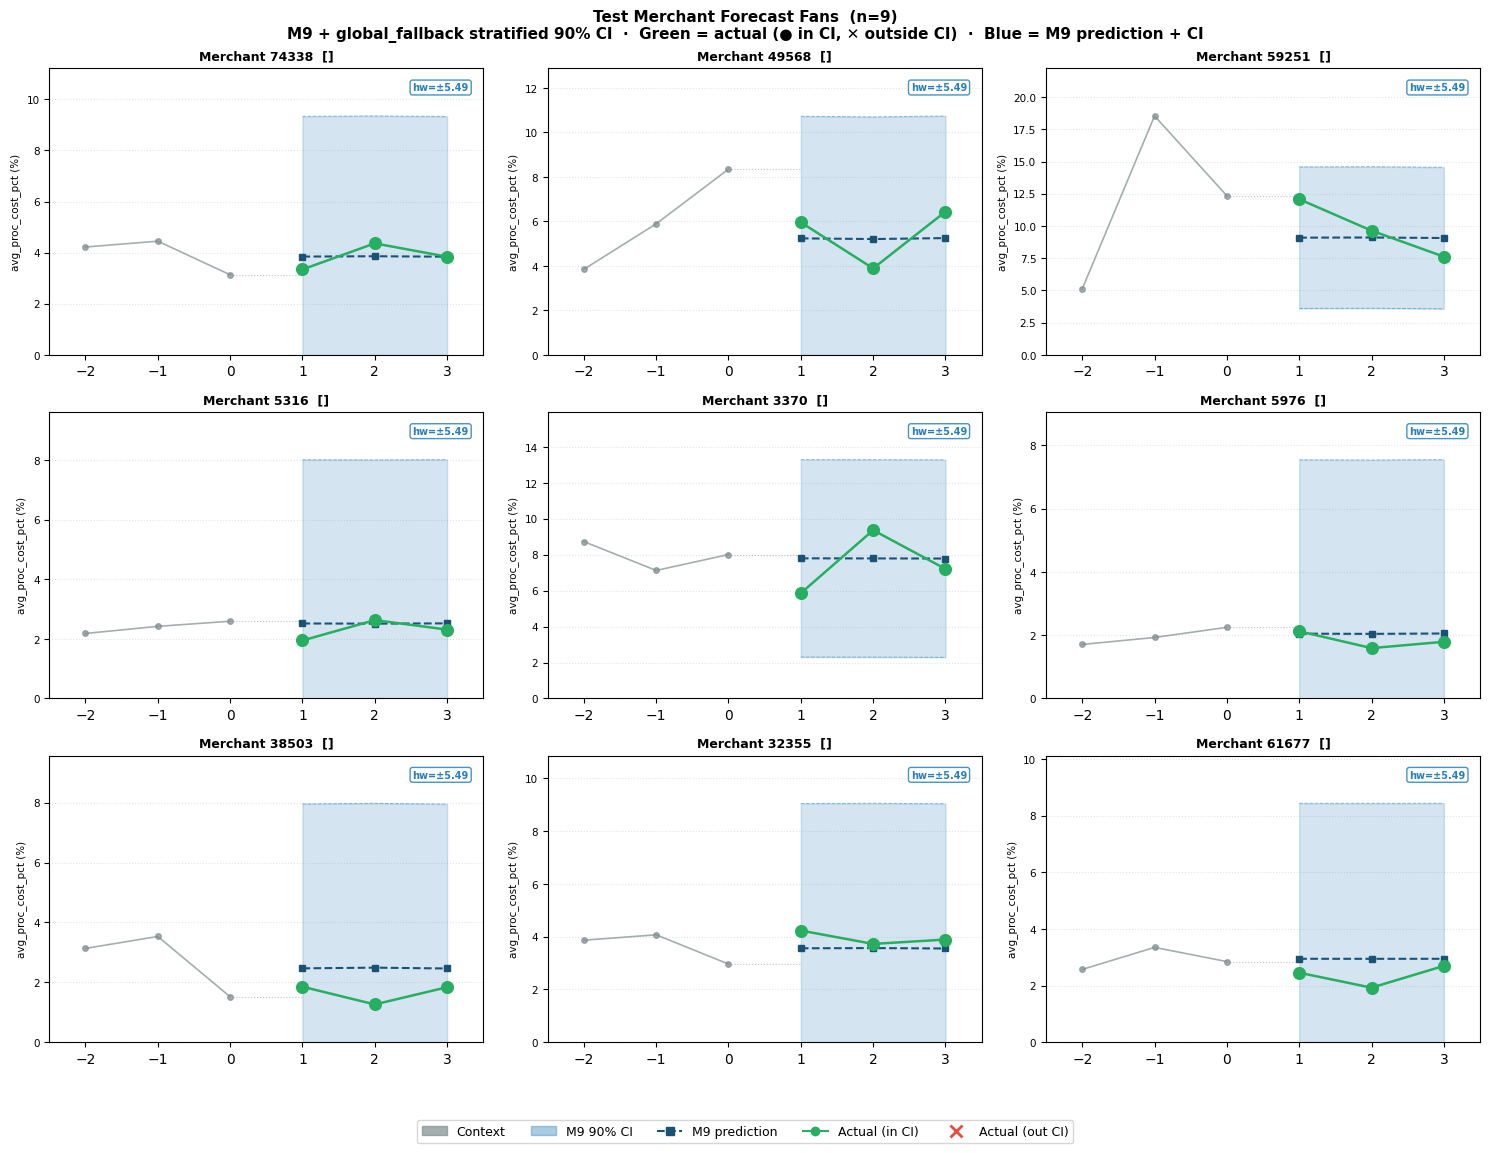

In [17]:
# ── Sample merchant forecast fans with deployed stratified intervals ──────────
_SAMPLE_N = 9
_VIS_SEED = 7

_mid_to_last = {}
for _idx, _s in enumerate(test_ci):
    _mid  = int(_s['merchant_id'])
    _ckey = _s['context_range'][1]
    if _mid not in _mid_to_last or _ckey > _mid_to_last[_mid][0]:
        _mid_to_last[_mid] = (_ckey, _idx)

_all_vis_mids = list(_mid_to_last.keys())
_rng_vis      = np.random.default_rng(_VIS_SEED)
_perm_vis     = _rng_vis.permutation(len(_all_vis_mids))
_sample_mids  = [_all_vis_mids[i] for i in _perm_vis[:_SAMPLE_N]]

ncols = 3
nrows = math.ceil(_SAMPLE_N / ncols)
x_step = np.array([1, 2, 3])

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.8), squeeze=False)
fig.suptitle(
    f'Test Merchant Forecast Fans  (n={_SAMPLE_N})\n'
    f'M9 + {VOL_SCHEME_NAME} stratified 90% CI  ·  '
    'Green = actual (● in CI, ✕ outside CI)  ·  Blue = M9 prediction + CI',
    fontsize=11, fontweight='bold'
)

for _plot_i, _mid in enumerate(_sample_mids):
    _row, _col = divmod(_plot_i, ncols)
    ax = axes[_row][_col]

    _, _idx = _mid_to_last[_mid]
    _s      = test_ci[_idx]

    ctx_vals = _s['context_data']['avg_proc_cost_pct'].values
    act      = y_te[_idx]
    pred     = te_preds_knn[_idx]
    lo_      = lo_strat_m9[_idx]
    hi_      = hi_strat_m9[_idx]

    _cy, _cm = _s['context_range'][1]
    _h_dates = [
        (int(_s['horizon_data'].iloc[h]['year']), int(_s['horizon_data'].iloc[h]['month']))
        for h in range(3)
    ]

    # Context trace
    ctx_x = np.arange(-len(ctx_vals) + 1, 1)
    ax.plot(ctx_x, ctx_vals, 'o-', color='#7f8c8d', markersize=4, linewidth=1.2, alpha=0.7)
    ax.plot([0, 1], [ctx_vals[-1], ctx_vals[-1]], ':', color='#7f8c8d', lw=0.8, alpha=0.5)

    # CI band + prediction
    ax.fill_between(x_step, lo_, hi_, alpha=0.2, color='#2980b9', zorder=2)
    ax.plot(x_step, lo_, '--', color='#2980b9', lw=0.7, alpha=0.5)
    ax.plot(x_step, hi_, '--', color='#2980b9', lw=0.7, alpha=0.5)
    ax.plot(x_step, pred, 's--', color='#1a5276', lw=1.5, markersize=5, zorder=5, label='M9 pred')

    # Actuals
    ax.plot(x_step, act, '-', color='#27ae60', lw=1.8, zorder=7)
    for h in range(3):
        _inside = lo_[h] <= act[h] <= hi_[h]
        ax.scatter([x_step[h]], [act[h]],
                   marker='o' if _inside else 'x',
                   color='#27ae60' if _inside else '#e74c3c',
                   s=55 if _inside else 80, zorder=8, lw=2)

    # Risk band label
    _band_lbl = VOL_LABELS_ACTIVE[int(te_vol_bins[_idx])] if N_VOL_BINS_ACTIVE > 1 else ''
    ax.set_title(f'Merchant {_mid}  [{_band_lbl}]', fontsize=9, fontweight='bold')
    ax.set_ylabel('avg_proc_cost_pct (%)', fontsize=7.5)
    ax.yaxis.set_tick_params(labelsize=7.5)
    ax.grid(axis='y', ls=':', alpha=0.35)
    y_max_vis = max(act.max(), hi_.max(), ctx_vals.max()) * 1.2
    ax.set_ylim(0, max(y_max_vis, 1))
    ax.set_xlim(ctx_x[0] - 0.5, 3.5)

    hw_val = float(np.mean(hi_ - pred))
    ax.text(3.3, ax.get_ylim()[1] * 0.95, f'hw=±{hw_val:.2f}',
            ha='right', va='top', fontsize=7, color='#2980b9', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.85, ec='#2980b9'))

for _plot_i in range(_SAMPLE_N, nrows * ncols):
    _row, _col = divmod(_plot_i, ncols)
    axes[_row][_col].set_visible(False)

_leg = [
    mpatches.Patch(color='#7f8c8d', alpha=0.7, label='Context'),
    mpatches.Patch(color='#2980b9', alpha=0.4, label='M9 90% CI'),
    plt.Line2D([0], [0], marker='s', color='#1a5276', ls='--', label='M9 prediction'),
    plt.Line2D([0], [0], marker='o', color='#27ae60', ls='-', label='Actual (in CI)'),
    plt.Line2D([0], [0], marker='x', color='#e74c3c', ls='', ms=8, mew=2, label='Actual (out CI)'),
]
fig.legend(handles=_leg, loc='lower center', ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

## Summary

### Pipeline Configuration

| Parameter | Value |
|---|---|
| Dataset | MCC 5411 · `avg_proc_cost_pct` |
| Context length | 3 months |
| Horizon length | 3 months (t+1, t+2, t+3) |
| Model | M9 — k-NN Pool Huber (ε = 1.35) |
| Conformal method | Pool-local split conformal, `adaptive_q`, MIN_POOL = 10 |
| Risk model | GBR (120 trees, depth 2) on all 6 risk features |
| Stratification | Auto-selected scheme from candidate grid |
| Guard | Soft floor = 0.870, min gain = 0.05 pp |

### Deployed Results (Test Set — 2019)

| Metric | Flat (pool-local) | Stratified (gbr_all6) |
|---|---|---|
| Joint coverage | ~0.906 | ~0.892 |
| Avg half-width | ~±4.02 pp | ~±3.36 pp |
| Width reduction | — | ~−16% |

Stratification reduces average interval width by ~16% while maintaining coverage above the soft floor guard, enabling tighter uncertainty bands for stable merchants without sacrificing coverage for volatile ones.